# Run 2nd level analysis with nilearn (sessionxgroup interaction/stress effect)
& visualize & report

* run on `sciencecloud2` (in VS interface notebook!)
* needs all 1stlevel contrasts (both sessions)
* main analysis: columns=["main","group", "session", "group x session"] + subject_list

In [1]:
import pandas as pd
from nilearn import plotting
import numpy as np
import matplotlib.pyplot as plt
import os.path as op

#bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
bids_folder = '/mnt_01/ds-stressrisk'

orig_file = op.join(bids_folder,'group_assignmentList.csv')
group_mapping = pd.read_csv(orig_file)[['subject','group']]

In [11]:
contrats_names = ['v1','v2','vdif','v1-event','v2-event'] # representing con 1-5 respectively

In [29]:
con_n = 5
con_name = contrats_names[con_n -1]
in_model_name = '1stlevel_Vhat-1'
#ses = 1

In [30]:
#
import scipy.io as sio
#temp_SPM = load(fullfile(bids_folder,'derivatives','spm',subList{sub},sesList{ses},in_model_name, 'SPM.mat'))
#get_names = @(s) s.name;
#con_names = arrayfun(get_names, temp_SPM.SPM.xCon, 'UniformOutput', false)

ex_spm = sio.loadmat(op.join(bids_folder,'derivatives', 'spm', f'sub-01',f'ses-{ses}', in_model_name, 'SPM.mat' ))
sorted(ex_spm.keys())

['SPM', '__globals__', '__header__', '__version__']

In [31]:
#

scan_list = []
subject_list = []
session_list = []
group_list = []

for ses in [1,2]:
    for group in [0,1]:
        subList_fil = group_mapping[group_mapping['group'] == group]['subject'].tolist()
        for sub in subList_fil:
            con_file = op.join(bids_folder, 'derivatives', 'spm', f'sub-{sub:02d}',f'ses-{ses}', in_model_name, f'con_000{con_n}.nii')
            if op.isfile(con_file) and (sub not in (2 ,44)):
                scan_list.append(con_file)
                if ses == 1:
                    subject_list.append(sub)
                session_list.append(ses)
                group_list.append(group)
            else:
                print(f'sub-{sub:02d} ses-{ses} con-{con_n} not found')

group_array = np.array(group_list)
session_array = np.array(session_list) -1
group_session_int = group_array * session_array

print(len(scan_list))

sub-02 ses-1 con-5 not found
sub-44 ses-1 con-5 not found
sub-02 ses-2 con-5 not found
sub-44 ses-2 con-5 not found
96


In [32]:
n_subjects = int((len(scan_list)/2)) # len(subject_list)
subject_effect = np.vstack((np.eye(n_subjects), np.eye(n_subjects)))
np.shape(subject_effect)

(96, 48)

In [33]:
paired_design_matrix = pd.DataFrame(
    np.column_stack((np.ones(len(group_array)),group_array, session_array,group_session_int, subject_effect)),
    columns=["main","group", "session", "group x session"] + subject_list
)

In [34]:
# only interaction
paired_design_matrix = pd.DataFrame(
    np.column_stack((group_session_int, subject_effect)),
    columns=[ "group x session"] + subject_list
)

In [ ]:
plotting.plot_design_matrix(paired_design_matrix)

In [36]:
from nilearn.glm.second_level import SecondLevelModel

model = SecondLevelModel(smoothing_fwhm=6.0, n_jobs=2)
model = model.fit(scan_list, design_matrix=paired_design_matrix)

In [37]:
contrast = 'group x session'# 'main'#
z_map = model.compute_contrast(second_level_contrast=contrast, output_type='z_score')

In [38]:
from scipy.stats import norm
p_val = 0.001
p001_uncorrected = norm.isf(p_val) # Inverse survival function (inverse of sf)., 3.09, associated T-value

from nilearn.glm import cluster_level_inference
spm_cluster_level_inf = cluster_level_inference(z_map, threshold=p001_uncorrected, alpha=0.05) # threshold=[3, 4, 5]

# mask corrected
import nibabel as nib

mpfc_mask_file = op.join(bids_folder, 'derivatives/surface_masks/mask_MarsAtlas_mPFC_MNI.nii')
mpfc_mask = nib.load(mpfc_mask_file)
spm_cluster_level_masked = cluster_level_inference(z_map, threshold=[3, 4, 5], alpha=0.05, mask_img=mpfc_mask)

/home/ubuntu/miniforge3/envs/nipype_spm/lib/python3.10/site-packages/nilearn/maskers/nifti_masker.py:110: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(
/home/ubuntu/miniforge3/envs/nipype_spm/lib/python3.10/site-packages/nilearn/maskers/nifti_masker.py:110: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


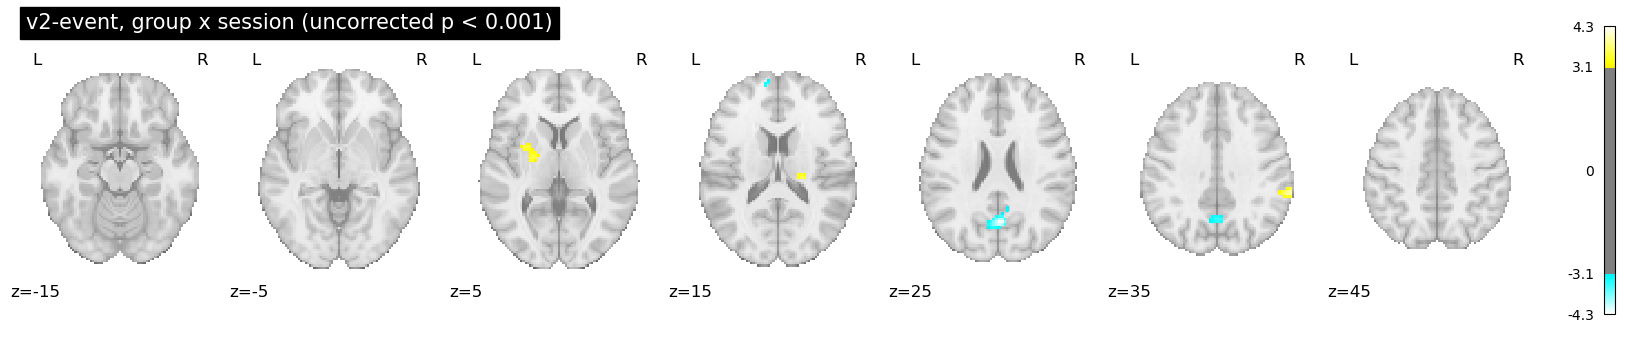

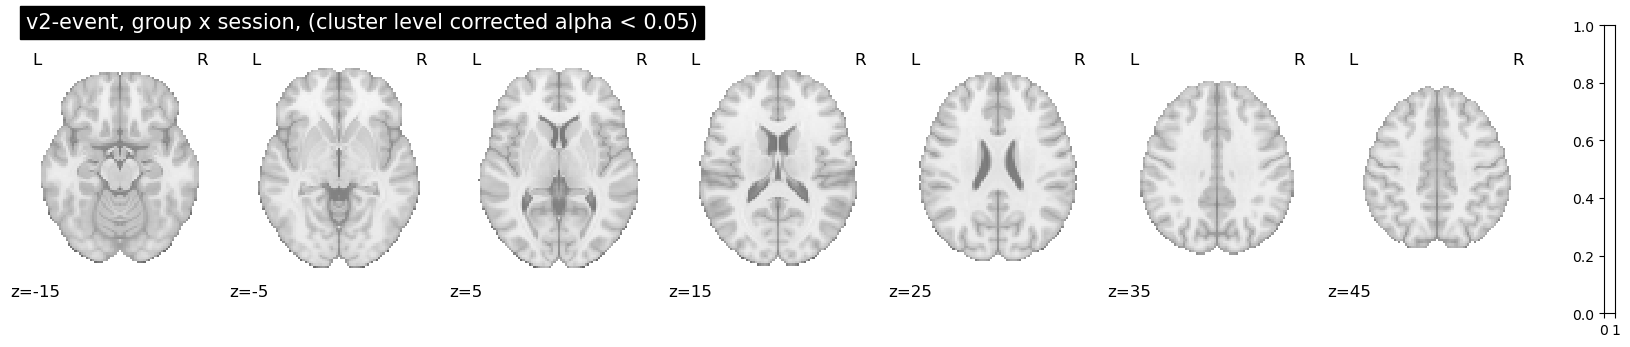

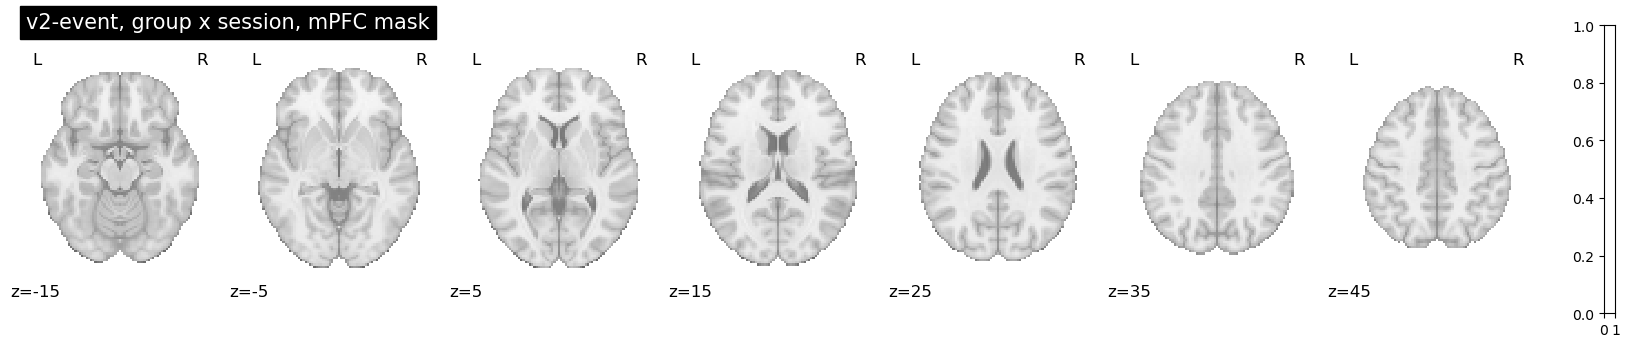

In [39]:
from nilearn import plotting

from nilearn import plotting
cut_coords = range(-15,50,10)
plotting.plot_stat_map(z_map,threshold=p001_uncorrected, display_mode="z", cut_coords = cut_coords,colorbar=True,
    title=f"{con_name}, {contrast} (uncorrected p < 0.001)",)
plotting.plot_stat_map(spm_cluster_level_inf, threshold=0.0, display_mode="z",cut_coords = cut_coords, colorbar=True,
    title=f"{con_name}, {contrast}, (cluster level corrected alpha < 0.05)")
plotting.plot_stat_map(spm_cluster_level_masked, threshold=0.0, display_mode="z",cut_coords = cut_coords,colorbar=True,
    title=f"{con_name}, {contrast}, mPFC mask",)

plotting.show()

In [26]:
from nilearn import reporting

report_table = reporting.get_clusters_table(z_map,stat_threshold = p001_uncorrected, cluster_threshold=10, 
                             two_sided=False, min_distance=8.0)
report_table

,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,-9.0,-102.5,11.5,6.092502,13725
1,1a,-19.0,-87.5,-9.5,5.783280,
2,1b,13.5,-102.5,11.5,5.139536,
3,1c,11.0,-87.5,-9.5,4.099719,
4,2,3.5,25.0,14.5,3.950861,1068
5,2a,6.0,37.5,17.5,3.550196,
6,2b,-4.0,37.5,17.5,3.352459,
7,3,-4.0,-22.5,32.5,3.566305,281
8,4,11.0,35.0,56.5,3.435702,206
9,5,51.0,-25.0,-9.5,3.315909,225


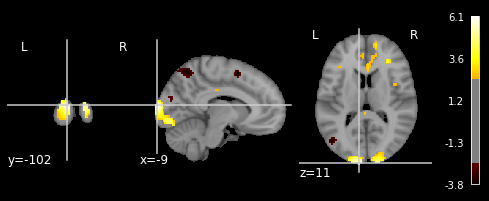

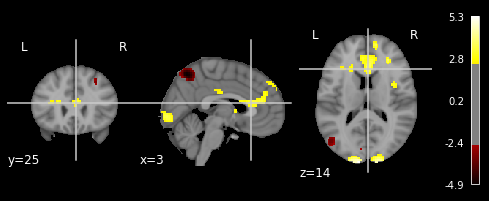

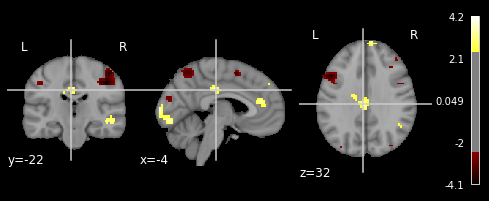

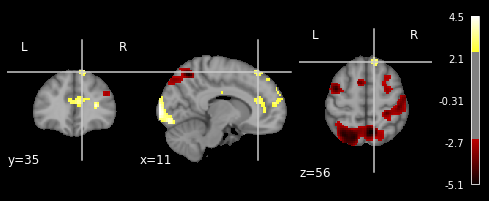

In [27]:
import nilearn.plotting as nipl 
import nibabel as nib
import matplotlib as mpl

anat_file = '/usr/local/fsl/data/standard/MNI152_T1_1mm_brain.nii.gz'
anat = nib.load(anat_file)

for cluster_id in range(1,5):
    coords = report_table[report_table['Cluster ID']==cluster_id][['X','Y','Z']].values.tolist()[0]
    display = nipl.plot_anat(anat_img = anat, cut_coords = (coords[0], coords[1], coords[2]))
    display.add_overlay(z_map, threshold = 2.5, colorbar=True, cmap = mpl.colormaps['hot'])   